# CELL MESH Demo: HNSC Sample-aware Workflow

This notebook mirrors the HNSC demo workflow but runs `run_cell_mesh()` with `sample_mode="sample_aware"`.

It is intended as a compact test notebook for the sample-aware path:

1. Use `Patient` as `sample_key` and `Celltype (malignancy)` as `cell_type_key`.
2. Filter packaged priors to expressed genes and a small reproducible metabolite subset.
3. Run sample-aware scoring with within-sample permutation.
4. Inspect sample validation, sample-level outputs, cross-sample aggregation, FDR columns, and visual summaries.


## 1. Imports

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cellmesh
from cellmesh import read_anndata, load_cell_mesh_database, run_cell_mesh
from cellmesh.ploting import plot_significant_event_counts, plot_event_dotplot

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

print("cellmesh", cellmesh.__version__)
print("cellmesh path:", cellmesh.__file__)

cellmesh 0.4.0
cellmesh path: /home/qsong/.openclaw/workspace/developer/cell_mesh_pkg/cellmesh/__init__.py


## 2. Load the Demo h5ad File

The 200-cell HNSC demo file contains a real `Patient` column, which is used here as `sample_key`. Because the dataset is intentionally small, this notebook uses `min_cells=2` to retain enough `(patient, cell type)` units for sample-aware testing.

In [2]:
adata_path = PROJECT_ROOT / "cellmesh" / "data" / "demo_HNSC_200cell.h5ad"
adata = read_anndata(adata_path)

cell_type_key = "Celltype (malignancy)"
sample_key = "Patient"

print(adata)
print("cell_type_key:", cell_type_key)
print("sample_key:", sample_key)
display(adata.obs[cell_type_key].value_counts().to_frame("n_cells"))
display(adata.obs[sample_key].value_counts().to_frame("n_cells").head(20))
display(pd.crosstab(adata.obs[sample_key], adata.obs[cell_type_key]))

AnnData object with n_obs × n_vars = 200 × 18241
    obs: 'UMAP_1', 'UMAP_2', 'Celltype (malignancy)', 'celltype', 'Celltype (minor-lineage)', 'Celltype (original)', 'cluster', 'Site', 'Celltype', 'Patient', 'Source', 'Age', 'Gender', 'Stage', 'TNMstage'
cell_type_key: Celltype (malignancy)
sample_key: Patient


,n_cells
Celltype (malignancy),
Malignant cells,84
Stromal cells,68
Immune cells,48


,n_cells
Patient,
HNSCC20,26
HNSCC16,23
HNSCC18,19
HN28,17
HNSCC25,16
HNSCC26,12
HNSCC6,12
HNSCC9,11
HN25,10


Celltype (malignancy),Immune cells,Malignant cells,Stromal cells
Patient,,,
HN23,1,0,0
HN25,1,2,7
HN26,1,6,2
HN28,1,4,12
HNSCC5,1,2,4
HNSCC6,1,8,3
HNSCC8,0,0,2
HNSCC9,9,1,1
HNSCC10,1,0,3


## 3. Load and Filter Packaged Priors

For runtime control, this notebook follows the pooled HNSC demo and selects a small reproducible set of metabolite/HMDB pairs that have both enzyme and sensor evidence in the h5ad gene space.

In [3]:
enzyme_metabolite, metabolite_sensor = load_cell_mesh_database()
genes_present = set(pd.Index(adata.var_names).astype(str))

enzyme_present = enzyme_metabolite[enzyme_metabolite["gene"].astype(str).isin(genes_present)].copy()
sensor_present = metabolite_sensor[metabolite_sensor["sensor_gene"].astype(str).isin(genes_present)].copy()

matched_pairs = sorted(
    set(zip(enzyme_present["metabolite"], enzyme_present["hmdb_id"]))
    .intersection(set(zip(sensor_present["metabolite"], sensor_present["hmdb_id"])))
)

MAX_METABOLITES = 10
selected_pairs = pd.DataFrame(matched_pairs[:MAX_METABOLITES], columns=["metabolite", "hmdb_id"])
enzyme_demo = enzyme_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])
sensor_demo = sensor_present.merge(selected_pairs, on=["metabolite", "hmdb_id"])

print("loaded enzyme prior:", enzyme_metabolite.shape)
print("loaded sensor prior:", metabolite_sensor.shape)
print("enzyme rows with expressed genes:", enzyme_present.shape)
print("sensor rows with expressed genes:", sensor_present.shape)
print("matched metabolite/HMDB pairs:", len(matched_pairs))
print("demo enzyme prior:", enzyme_demo.shape)
print("demo sensor prior:", sensor_demo.shape)
display(selected_pairs)

loaded enzyme prior: (12799, 8)
loaded sensor prior: (9858, 9)
enzyme rows with expressed genes: (11757, 8)
sensor rows with expressed genes: (7746, 9)
matched metabolite/HMDB pairs: 245
demo enzyme prior: (43, 8)
demo sensor prior: (51, 9)


,metabolite,hmdb_id
0,(R)-5-Diphosphomevalonic acid,HMDB0001090
1,11-cis-Retinol,HMDB0006216
2,11beta-Hydroxyprogesterone,HMDB0004031
3,12-HETE,HMDB0006111
4,13-cis-Retinoic acid,HMDB0006219
5,15-HETE,HMDB0003876
6,16a-Hydroxyestrone,HMDB0000335
7,17-Hydroxyprogesterone,HMDB0000374
8,17alpha-Estradiol,HMDB0000429
9,2-Hydroxyestradiol,HMDB0000338


## 4. Run CELL MESH in Sample-aware Mode

`sample_mode="sample_aware"` computes pseudobulks and scores separately for each eligible `(sample, cell type)` unit, then aggregates event scores across samples. With `sample_key` provided, permutations are within-sample label shuffles over the fixed eligible analysis cells.

In [4]:
res = run_cell_mesh(
    adata,
    enzyme_metabolite=enzyme_demo,
    metabolite_sensor=sensor_demo,
    cell_type_key=cell_type_key,
    sample_key=sample_key,
    sample_mode="sample_aware",
    min_cells=2,
    min_expr_frac=0.05,
    allow_self=True,
    n_perms=10,
    random_state=0,
)

print("events:", res.events.shape)
print("sender_scores:", res.sender_scores.shape)
print("receiver_scores:", res.receiver_scores.shape)
print("sample_validation:", res.sample_validation.shape)
print("sample_sender_scores:", res.sample_sender_scores.shape)
print("sample_receiver_scores:", res.sample_receiver_scores.shape)
print("sample_events:", res.sample_events.shape)
print("availability result keys:", sorted(res.availability_results.keys()))
print("events with permutation p-value:", res.events["perm_pvalue"].notna().sum())
print("events with global FDR:", res.events["fdr_global"].notna().sum())
print("events with sensor-type FDR:", res.events["fdr_sensor_type"].notna().sum())
print("permutation modes:", sorted(res.events["permutation_mode"].dropna().unique()))
print("inference modes:", sorted(res.events["inference_mode"].dropna().unique()))

null_scores = res.events.attrs.get("sample_aware_null_scores")
print("sample-aware null score matrix:", None if null_scores is None else null_scores.shape)

events: (441, 25)
sender_scores: (8, 3)
receiver_scores: (153, 9)
sample_validation: (45, 6)
sample_sender_scores: (101, 3)
sample_receiver_scores: (1530, 9)
sample_events: (7938, 13)
availability result keys: ['availability_by_sample', 'sample_event_scores', 'sample_events', 'sample_receiver_scores', 'sample_sender_scores', 'sample_validation']
events with permutation p-value: 441
events with global FDR: 441
events with sensor-type FDR: 441
permutation modes: ['within_sample_label_shuffle']
inference modes: ['sample_aware']
sample-aware null score matrix: (441, 10)


## 5. Inspect Sample Eligibility

`sample_validation` reports cell counts and eligibility for every observed `(sample, cell type)` unit. Units below `min_cells` are excluded from sample-level pseudobulk calculation and remain missing values in sample-level outputs.

,sample,cell_type,n_cells,eligible_in_sample,n_eligible_celltypes_in_sample,n_valid_samples_for_celltype
0,HN23,Immune cells,1,False,0,6
1,HN25,Immune cells,1,False,2,6
2,HN25,Malignant cells,2,True,2,11
3,HN25,Stromal cells,7,True,2,13
4,HN26,Immune cells,1,False,2,6
5,HN26,Malignant cells,6,True,2,11
6,HN26,Stromal cells,2,True,2,13
7,HN28,Immune cells,1,False,2,6
8,HN28,Malignant cells,4,True,2,11
9,HN28,Stromal cells,12,True,2,13


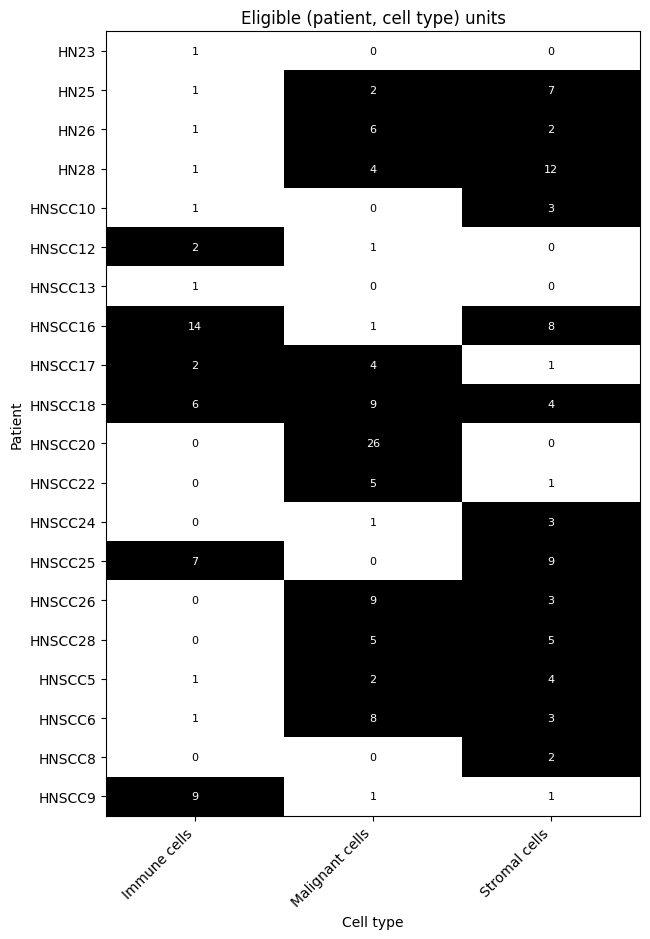

In [5]:
validation = res.sample_validation.copy()
display(validation.sort_values(["sample", "cell_type"]).head(30))

eligibility_matrix = validation.pivot(index="sample", columns="cell_type", values="eligible_in_sample").eq(True)
count_matrix = validation.pivot(index="sample", columns="cell_type", values="n_cells").fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(1.2 * eligibility_matrix.shape[1] + 3, 0.35 * eligibility_matrix.shape[0] + 2.5))
image = ax.imshow(eligibility_matrix.to_numpy(dtype=float), cmap="Greys", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(eligibility_matrix.shape[1]))
ax.set_xticklabels(eligibility_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(eligibility_matrix.shape[0]))
ax.set_yticklabels(eligibility_matrix.index)
ax.set_xlabel("Cell type")
ax.set_ylabel("Patient")
ax.set_title("Eligible (patient, cell type) units")
for i, sample in enumerate(eligibility_matrix.index):
    for j, cell_type in enumerate(eligibility_matrix.columns):
        value = count_matrix.loc[sample, cell_type]
        color = "white" if eligibility_matrix.loc[sample, cell_type] else "black"
        ax.text(j, i, str(value), ha="center", va="center", fontsize=8, color=color)
plt.tight_layout()
plt.show()

## 6. Inspect Top Sample-aware Events

In [6]:
event_cols = [
    "sender",
    "receiver",
    "metabolite",
    "hmdb_id",
    "sensor_gene",
    "sensor_type",
    "cell_mesh_score",
    "event_score_median",
    "event_score_iqr",
    "n_samples_coobserved",
    "n_samples_positive",
    "event_prevalence",
    "perm_pvalue",
    "fdr_global",
    "fdr_sensor_type",
    "fdr",
    "permutation_mode",
    "inference_mode",
    "confidence_tier",
]

display(res.events[event_cols].head(25))

coverage_summary = (
    res.events.groupby("n_samples_coobserved")
    .size()
    .rename("n_events")
    .reset_index()
    .sort_values("n_samples_coobserved")
)
display(coverage_summary)

,sender,receiver,metabolite,hmdb_id,sensor_gene,sensor_type,cell_mesh_score,event_score_median,event_score_iqr,n_samples_coobserved,n_samples_positive,event_prevalence,perm_pvalue,fdr_global,fdr_sensor_type,fdr,permutation_mode,inference_mode,confidence_tier
0,Malignant cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,Other receptor,1.000000,1.000000,NaN,1,1,1.000000,0.181818,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
1,Malignant cells,Immune cells,13-cis-Retinoic acid,HMDB0006219,RXRB,Other receptor,0.769174,0.769174,NaN,1,1,1.000000,0.090909,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
2,Stromal cells,Immune cells,17-Hydroxyprogesterone,HMDB0000374,VDR,Other receptor,0.467162,0.467162,0.467162,2,1,0.500000,0.090909,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
3,Stromal cells,Immune cells,17-Hydroxyprogesterone,HMDB0000374,NR3C1,Other receptor,0.425831,0.425831,0.425831,2,1,0.500000,0.090909,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
4,Stromal cells,Immune cells,17-Hydroxyprogesterone,HMDB0000374,RXRB,Other receptor,0.379669,0.379669,0.379669,2,1,0.500000,0.090909,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
5,Immune cells,Immune cells,13-cis-Retinoic acid,HMDB0006219,RARA,Other receptor,0.333333,0.333333,0.166667,3,2,0.666667,0.272727,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
6,Immune cells,Stromal cells,13-cis-Retinoic acid,HMDB0006219,RXRB,Other receptor,0.191946,0.191946,0.166667,3,2,0.666667,0.181818,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
7,Stromal cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,Other receptor,0.166667,0.166667,0.166667,2,1,0.500000,0.181818,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
8,Stromal cells,Immune cells,17-Hydroxyprogesterone,HMDB0000374,RARA,Other receptor,0.136083,0.136083,0.136083,2,1,0.500000,0.272727,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory
9,Stromal cells,Immune cells,17-Hydroxyprogesterone,HMDB0000374,NR2C1,Other receptor,0.136083,0.136083,0.136083,2,1,0.500000,0.181818,1.0,1.0,1.0,within_sample_label_shuffle,sample_aware,Tier3_exploratory


,n_samples_coobserved,n_events
0,1,27
1,2,159
2,3,59
3,4,1
4,5,1
5,6,2
6,7,12
7,8,95
8,9,6
9,10,34


## 7. Sample-level Scores for One Event

The aggregated event score is the median of non-missing sample-level event scores. The IQR summarizes between-sample variability when at least two sample-level scores are available.

target event key: ('Malignant cells', 'Malignant cells', '11beta-Hydroxyprogesterone', 'HMDB0004031', 'NR3C2', 'Other receptor')


,value
sender,Malignant cells
receiver,Malignant cells
metabolite,11beta-Hydroxyprogesterone
hmdb_id,HMDB0004031
sensor_gene,NR3C2
sensor_type,Other receptor
cell_mesh_score,1.0
event_score_median,1.0
event_score_iqr,NaN
n_samples_coobserved,1


,sample_event_score
sample,
HNSCC18,1.0


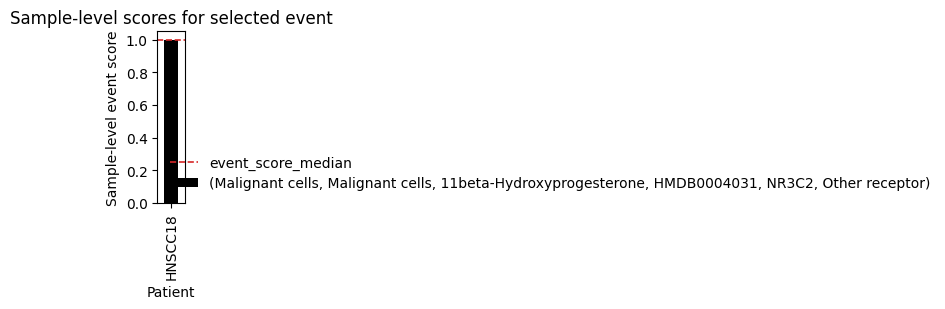

In [7]:
assert not res.events.empty

target_event = res.events.sort_values(
    ["fdr_sensor_type", "cell_mesh_score"],
    ascending=[True, False],
    na_position="last",
).iloc[0]
event_key_cols = ["sender", "receiver", "metabolite", "hmdb_id", "sensor_gene", "sensor_type"]
target_key = tuple(target_event[col] for col in event_key_cols)

print("target event key:", target_key)
display(target_event[event_cols].to_frame("value"))

sample_event_scores = res.availability_results["sample_event_scores"]
target_sample_scores = sample_event_scores.loc[target_key].dropna().sort_values(ascending=False)
display(target_sample_scores.to_frame("sample_event_score"))

fig, ax = plt.subplots(figsize=(max(5, 0.5 * len(target_sample_scores) + 2), 3.2))
target_sample_scores.plot(kind="bar", ax=ax, color="black")
ax.axhline(target_event["event_score_median"], color="tab:red", linestyle="--", linewidth=1.2, label="event_score_median")
ax.set_ylabel("Sample-level event score")
ax.set_xlabel("Patient")
ax.set_title("Sample-level scores for selected event")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 8. Global Overview: Event Counts After Thresholding

This reuses the standard global event count plot. For this small sample-aware demo and `n_perms=10`, `max_fdr` is intentionally relaxed; adjust the thresholds below for stricter checks.

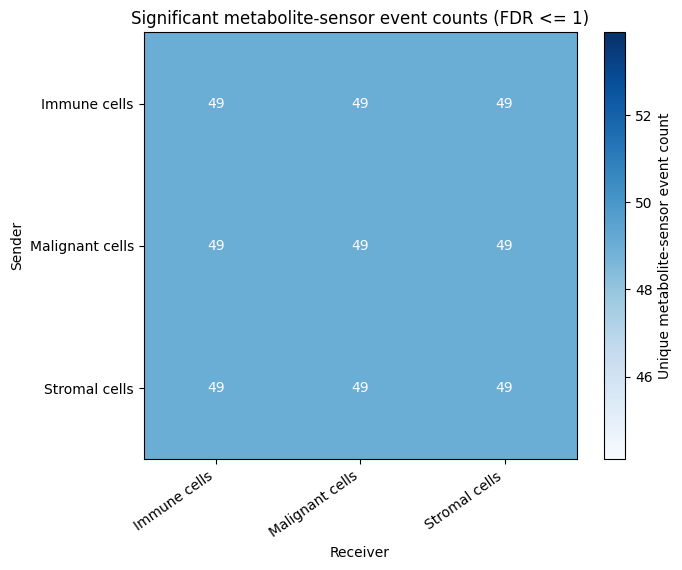

{'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': 1.0, 'events_before_filter': 441, 'events_after_filter': 441, 'unique_events_after_filter': 441}


,sender,receiver,metabolite_sensor_count
0,Immune cells,Immune cells,49
1,Immune cells,Malignant cells,49
2,Immune cells,Stromal cells,49
3,Malignant cells,Immune cells,49
4,Malignant cells,Malignant cells,49
5,Malignant cells,Stromal cells,49
6,Stromal cells,Immune cells,49
7,Stromal cells,Malignant cells,49
8,Stromal cells,Stromal cells,49


In [8]:
min_cell_mesh_score = None
max_perm_pvalue = None
max_fdr = 1.0

sig_overview = plot_significant_event_counts(
    res,
    min_cell_mesh_score=min_cell_mesh_score,
    max_perm_pvalue=max_perm_pvalue,
    max_fdr=max_fdr,
)
plt.show()

print(sig_overview["thresholds"])
display(sig_overview["summary"])

## 9. Dotplot: Top Sample-aware Communication Events

Rows are metabolite-sensor events (`metabolite -> sensor_gene`), columns are receiver cell types within sender-specific panels, color encodes `Cellmesh_score`, and bubble size represents FDR on the existing `-log10(FDR)` size scale.

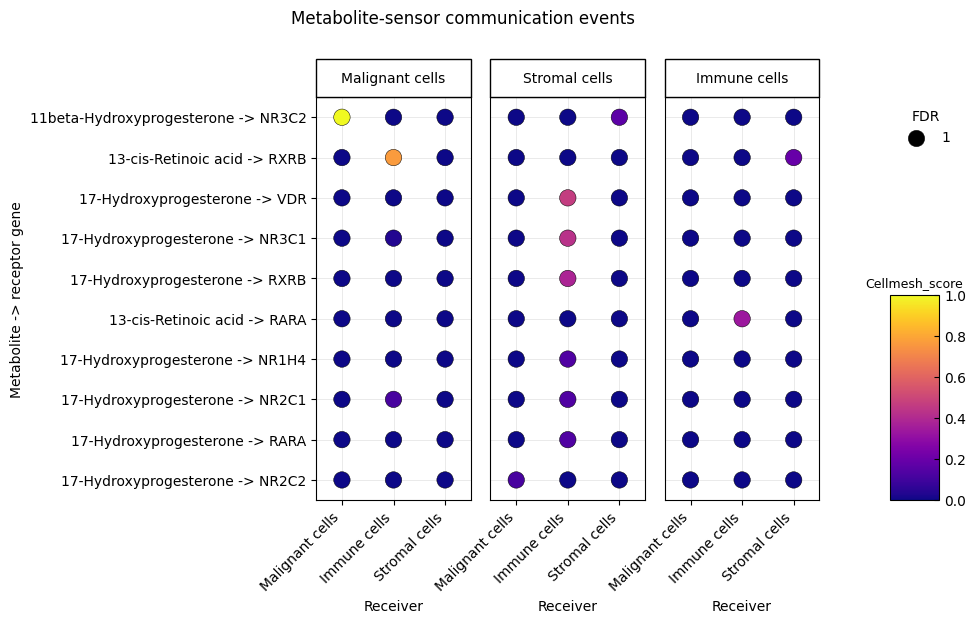

{'top_n': 10, 'event_keys': None, 'min_cell_mesh_score': None, 'max_perm_pvalue': None, 'max_fdr': None, 'events_before_filter': 441, 'events_after_filter': 441, 'events_plotted': 90}


,sender,receiver,metabolite,hmdb_id,sensor_gene,cell_mesh_score,perm_pvalue,fdr
303,Immune cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
310,Immune cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
262,Immune cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
430,Malignant cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
0,Malignant cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,1.000000,0.181818,1.0
67,Malignant cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
37,Stromal cells,Immune cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
197,Stromal cells,Malignant cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.000000,1.000000,1.0
7,Stromal cells,Stromal cells,11beta-Hydroxyprogesterone,HMDB0004031,NR3C2,0.166667,0.181818,1.0
5,Immune cells,Immune cells,13-cis-Retinoic acid,HMDB0006219,RARA,0.333333,0.272727,1.0


In [9]:
event_dotplot_top = plot_event_dotplot(
    res,
    top_n=10,
    event_keys=None,
    max_fdr=None,
)
plt.show()

print(event_dotplot_top["thresholds"])
display(
    event_dotplot_top["plot_events"][
        [
            "sender",
            "receiver",
            "metabolite",
            "hmdb_id",
            "sensor_gene",
            "cell_mesh_score",
            "perm_pvalue",
            "fdr",
        ]
    ].head(30)
)

## 10. Sample-aware Output Checks

These lightweight assertions are meant to make the notebook useful as a smoke test for the sample-aware API.

In [10]:
required_event_columns = {
    "event_score_median",
    "event_score_iqr",
    "n_samples_coobserved",
    "n_samples_positive",
    "event_prevalence",
    "perm_pvalue",
    "fdr_global",
    "fdr_sensor_type",
    "permutation_mode",
    "inference_mode",
}
missing = required_event_columns.difference(res.events.columns)
assert not missing, missing
assert set(res.events["inference_mode"].dropna()) == {"sample_aware"}
assert set(res.events["permutation_mode"].dropna()) == {"within_sample_label_shuffle"}
assert res.sample_validation is not None and not res.sample_validation.empty
assert res.sample_sender_scores is not None
assert res.sample_receiver_scores is not None
assert res.sample_events is not None
assert null_scores is not None and null_scores.shape[1] == 10

print("sample-aware smoke checks passed")

sample-aware smoke checks passed
